# Riskfolio-Lib Tutorial: 
<br><a href="https://www.kqzyfj.com/click-101360347-15150084?url=https%3A%2F%2Flink.springer.com%2Fbook%2F9783031843037" target="_blank">
<div>
<img src="https://raw.githubusercontent.com/dcajasn/Riskfolio-Lib/refs/heads/master/docs/source/_static/Button.png" height="40" />
</div>
<br>
</a>
<a href="https://www.paypal.com/ncp/payment/GN55W4UQ7VAMN" target="_blank">
<div>
<img src="https://raw.githubusercontent.com/dcajasn/Riskfolio-Lib/refs/heads/master/docs/source/_static/Button2.png" height="40" />
</div>
</a>

<br><a href='https://ko-fi.com/B0B833SXD' target='_blank'><img height='36' style='border:0px;height:36px;' src='https://cdn.ko-fi.com/cdn/kofi1.png?v=2' border='0' alt='Buy Me a Coffee at ko-fi.com' /></a> 
<br>
<br>__[Financionerioncios](https://financioneroncios.wordpress.com)__
<br>__[Orenji](https://www.linkedin.com/company/orenj-i)__
<br>__[Riskfolio-Lib](https://portfoliooptimization.org)__
<br>__[Dany Cajas](https://www.linkedin.com/in/dany-cajas/)__

## Tutorial 25: Hierarchical Equal Risk Contribution (HERC) Portfolio Optimization

## 1. Downloading the data:

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings

warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.4%}'.format

# Date range
start = '2016-01-01'
end = '2019-12-30'

# Tickers of assets
assets = ['JCI', 'TGT', 'CMCSA', 'CPB', 'MO', 'APA', 'MRSH', 'JPM',
          'ZION', 'PSA', 'BAX', 'BMY', 'LUV', 'PCAR', 'TXT', 'TMO',
          'DE', 'MSFT', 'HPQ', 'SHW', 'VZ', 'CNP', 'NI', 'T', 'BA']
assets.sort()

# Downloading data
data = yf.download(assets, start = start, end = end, auto_adjust=False)
data = data.loc[:,('Adj Close', slice(None))]
data.columns = assets

[*********************100%***********************]  25 of 25 completed


In [2]:
# Calculating returns

Y = data[assets].pct_change().dropna()

display(Y.head())

,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,HPQ,JCI,...,NI,PCAR,PSA,SHW,T,TGT,TMO,TXT,VZ,ZION
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-05,-2.0257%,0.4057%,0.4036%,1.9693%,0.0180%,0.9305%,0.3678%,0.5783%,0.9483%,-1.1954%,...,1.5881%,0.0212%,2.8236%,0.4044%,0.6987%,1.7539%,-0.1729%,0.2410%,1.3734%,-1.0857%
2016-01-06,-11.4863%,-1.5879%,0.2412%,-1.7557%,-0.7727%,-1.2473%,-0.1736%,-1.1239%,-3.5867%,-0.9551%,...,0.5547%,0.0212%,0.1592%,-2.8931%,0.3107%,-1.0155%,-0.7653%,-3.0048%,-0.9035%,-2.9145%
2016-01-07,-5.1389%,-4.1922%,-1.6573%,-2.7699%,-1.1047%,-1.9769%,-1.2207%,-0.8856%,-4.6058%,-2.5394%,...,-2.2066%,-3.0309%,-1.0410%,-2.7418%,-1.6148%,-0.2700%,-2.2844%,-2.0570%,-0.5492%,-3.0019%
2016-01-08,0.2736%,-2.2705%,-1.6037%,-2.5425%,0.1099%,-0.2241%,0.5707%,-1.6402%,-1.7642%,-0.1649%,...,-0.1539%,-1.1366%,-0.7308%,0.0828%,0.0895%,-3.3838%,-0.1117%,-1.1387%,-0.9719%,-1.1254%
2016-01-11,-4.3384%,0.1692%,-1.6851%,-1.0215%,0.0915%,-1.1791%,0.5674%,0.5288%,0.6616%,0.0331%,...,1.6436%,0.0000%,0.9870%,0.0828%,1.2225%,1.4570%,0.5366%,-0.4607%,0.5799%,-1.9919%


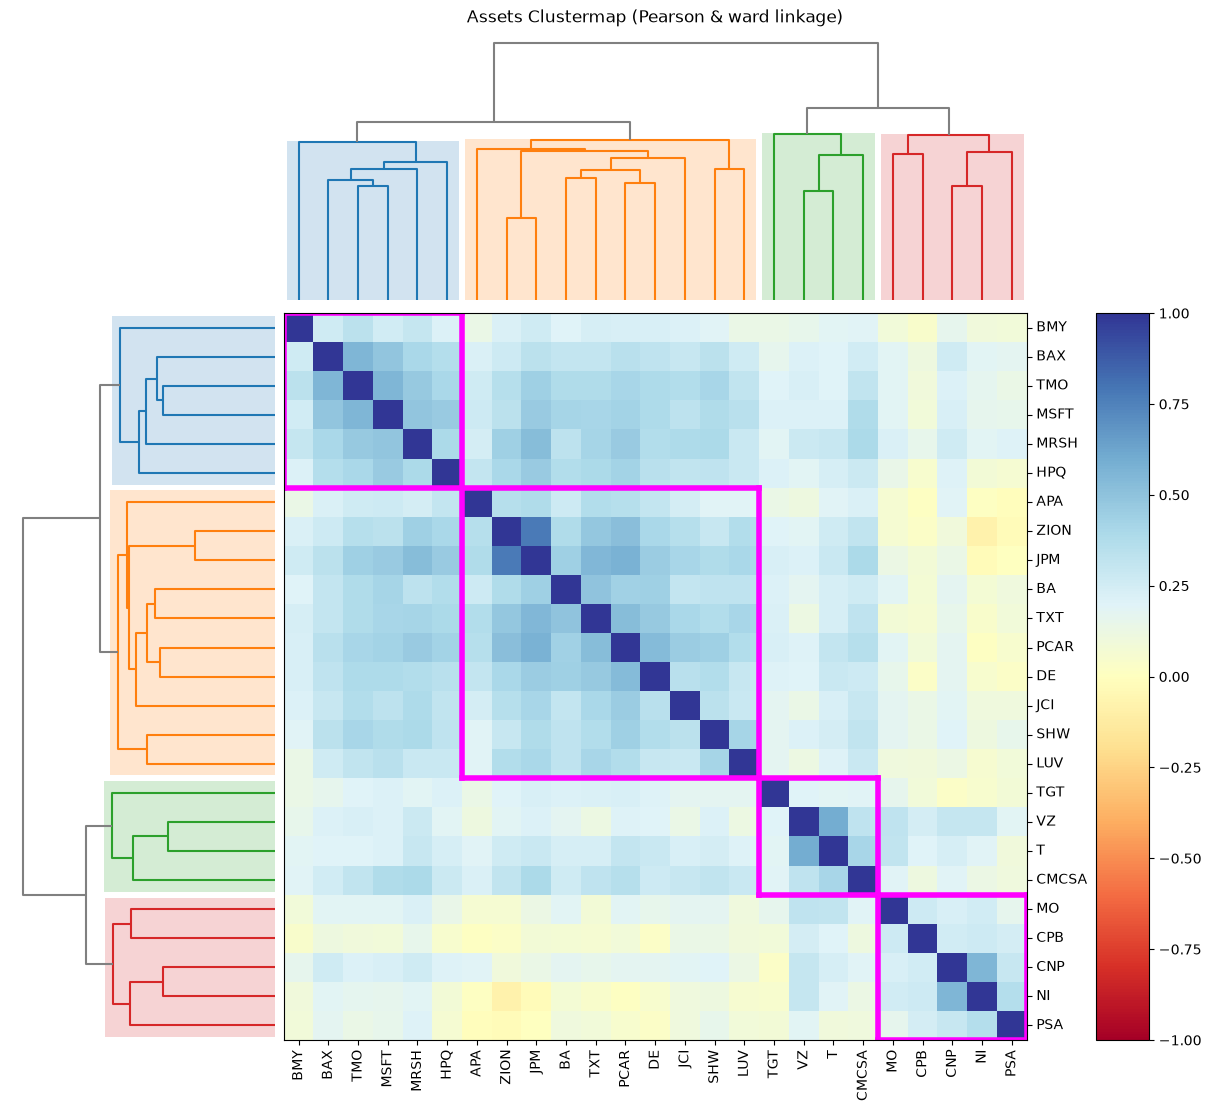

In [3]:
import riskfolio as rp

# Plotting Assets Clusters

ax = rp.plot_clusters(returns=Y,
                      codependence='pearson',
                      linkage='ward',
                      k=None,
                      max_k=10,
                      leaf_order=True,
                      dendrogram=True,
                      #linecolor='tab:purple',
                      ax=None)

The graph above suggest that optimal number of clusters are four.

## 2. Estimating HERC Portfolio

This is the original model proposed by Raffinot (2018). Riskfolio-Lib expand this model to 32 risk measures.

### 2.1 Calculating the HERC portfolio

In [4]:
# Building the portfolio object
port = rp.HCPortfolio(returns=Y)

# Estimate optimal portfolio:

model='HERC' # Could be HRP or HERC
codependence = 'pearson' # Correlation matrix used to group assets in clusters
rm = 'MV' # Risk measure used, this time will be variance
rf = 0 # Risk free rate
linkage = 'ward' # Linkage method used to build clusters
max_k = 10 # Max number of clusters used in two difference gap statistic
leaf_order = True # Consider optimal order of leafs in dendrogram

w = port.optimization(model=model,
                      codependence=codependence,
                      rm=rm,
                      rf=rf,
                      linkage=linkage,
                      max_k=max_k,
                      leaf_order=leaf_order)

display(w.T)

,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,HPQ,JCI,...,NI,PCAR,PSA,SHW,T,TGT,TMO,TXT,VZ,ZION
weights,0.6319%,1.7031%,4.5470%,2.6430%,5.8214%,7.6169%,3.8904%,1.7054%,2.2500%,2.2141%,...,7.3459%,2.0888%,6.9218%,2.4914%,7.7150%,3.1756%,4.0417%,1.8180%,8.7585%,1.6007%


### 2.2 Plotting portfolio composition

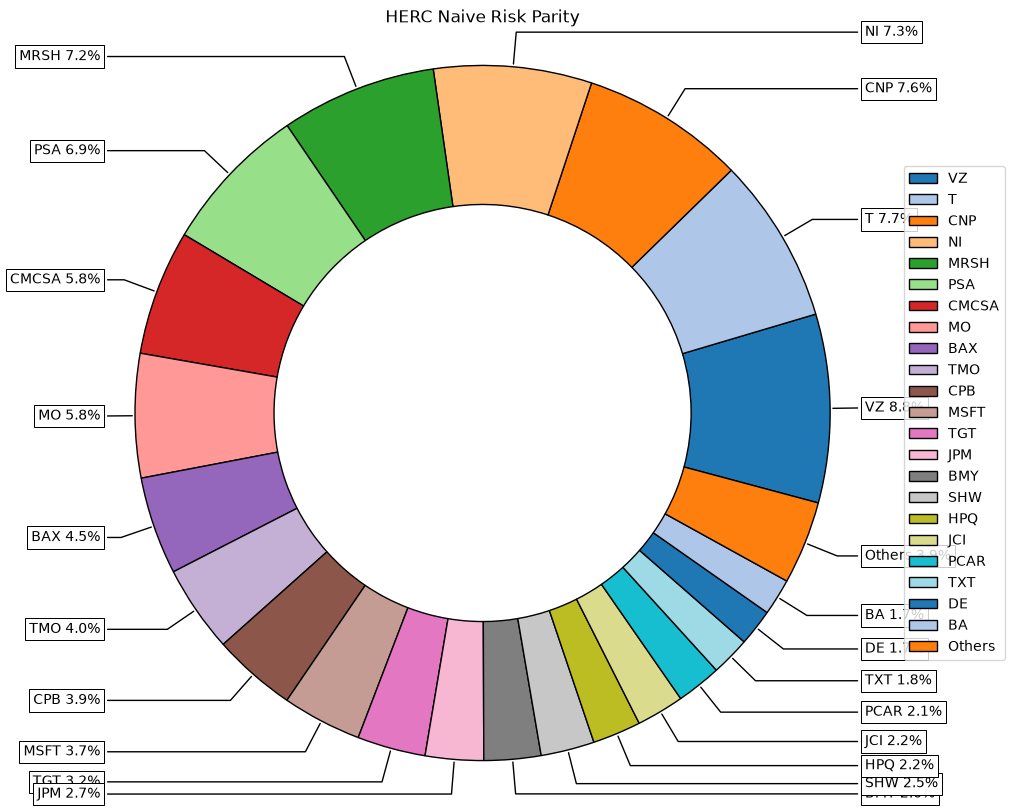

In [5]:
# Plotting the composition of the portfolio

ax = rp.plot_pie(w=w,
                 title='HERC Naive Risk Parity',
                 others=0.05,
                 nrow=25,
                 cmap="tab20",
                 height=8,
                 width=10,
                 ax=None)

### 2.3 Plotting Risk Contribution

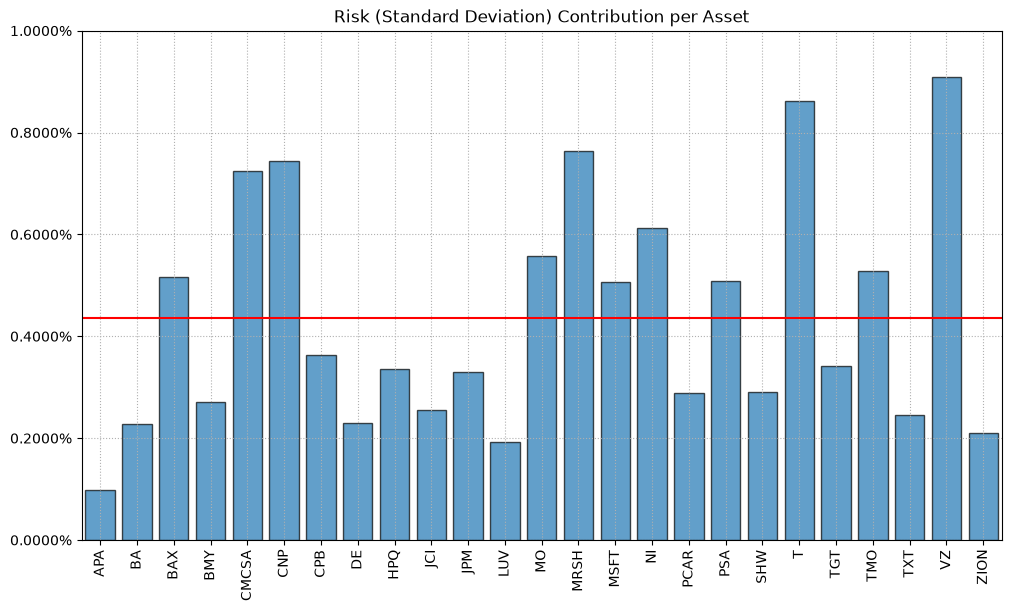

In [6]:
# Plotting the risk contribution per asset

mu = Y.mean()
cov = Y.cov() # Covariance matrix
returns = Y # Returns of the assets

ax = rp.plot_risk_con(
    w=w,
    cov=cov,
    returns=returns,
    rm=rm,
    rf=0,
    alpha=0.05,
    color="tab:blue",
    height=6,
    width=10,
    t_factor=252,
    ax=None)

### 2.4 Calculate Optimal HERC Portfolios for Several Risk Measures

In [7]:
# Risk Measures available:
#
# 'vol': Standard Deviation.
# 'MV': Variance.
# 'MAD': Mean Absolute Deviation.
# 'GMD': Gini Mean Difference.
# 'MSV': Semi Standard Deviation.
# 'FLPM': First Lower Partial Moment (Omega Ratio).
# 'SLPM': Second Lower Partial Moment (Sortino Ratio).
# 'VaR': Conditional Value at Risk.
# 'CVaR': Conditional Value at Risk.
# 'TG': Tail Gini.
# 'EVaR': Entropic Value at Risk.
# 'WR': Worst Realization (Minimax).
# 'RG': Range of returns.
# 'CVRG': CVaR Range of returns.
# 'TGRG': Tail Gini Range of returns.
# 'MDD': Maximum Drawdown of uncompounded cumulative returns (Calmar Ratio).
# 'ADD': Average Drawdown of uncompounded cumulative returns.
# 'DaR': Drawdown at Risk of uncompounded cumulative returns.
# 'CDaR': Conditional Drawdown at Risk of uncompounded cumulative returns.
# 'EDaR': Entropic Drawdown at Risk of uncompounded cumulative returns.
# 'UCI': Ulcer Index of uncompounded cumulative returns.
# 'MDD_Rel': Maximum Drawdown of compounded cumulative returns (Calmar Ratio).
# 'ADD_Rel': Average Drawdown of compounded cumulative returns.
# 'DaR_Rel': Drawdown at Risk of compounded cumulative returns.
# 'CDaR_Rel': Conditional Drawdown at Risk of compounded cumulative returns.
# 'EDaR_Rel': Entropic Drawdown at Risk of compounded cumulative returns.
# 'UCI_Rel': Ulcer Index of compounded cumulative returns.

rms = ['vol', 'MV', 'MAD', 'GMD', 'MSV', 'FLPM', 'SLPM', 'VaR',
       'CVaR', 'TG', 'EVaR', 'WR', 'RG', 'CVRG', 'TGRG', 'MDD', 
       'ADD', 'DaR', 'CDaR', 'EDaR', 'UCI', 'MDD_Rel',
       'ADD_Rel', 'DaR_Rel', 'CDaR_Rel', 'EDaR_Rel', 'UCI_Rel']

w_s = pd.DataFrame([])

for i in rms:
    w = port.optimization(model=model,
                          codependence=codependence,
                          rm=i,
                          rf=rf,
                          linkage=linkage,
                          max_k=max_k,
                          leaf_order=leaf_order)

    w_s = pd.concat([w_s, w], axis=1)
    
w_s.columns = rms

In [8]:
w_s.style.format("{:.2%}").background_gradient(cmap='YlGn')

,vol,MV,MAD,GMD,MSV,FLPM,SLPM,VaR,CVaR,TG,EVaR,WR,RG,CVRG,TGRG,MDD,ADD,DaR,CDaR,EDaR,UCI,MDD_Rel,ADD_Rel,DaR_Rel,CDaR_Rel,EDaR_Rel,UCI_Rel
APA,1.28%,0.63%,1.26%,1.27%,1.33%,1.18%,1.28%,1.21%,1.34%,1.38%,1.44%,1.45%,1.18%,1.28%,1.30%,0.58%,0.44%,0.57%,0.55%,0.56%,0.50%,0.76%,0.51%,0.72%,0.71%,0.73%,0.59%
BA,2.10%,1.70%,2.13%,2.12%,2.07%,2.20%,2.10%,2.04%,1.96%,1.95%,2.07%,1.99%,1.86%,2.02%,2.01%,2.00%,2.32%,2.20%,2.04%,2.08%,2.22%,2.03%,2.26%,2.25%,2.06%,2.09%,2.21%
BAX,4.40%,4.55%,4.52%,4.47%,4.23%,4.70%,4.29%,4.30%,4.14%,4.07%,3.51%,3.33%,3.91%,4.32%,4.32%,4.27%,6.57%,5.31%,4.87%,4.55%,5.94%,4.33%,6.67%,5.31%,4.87%,4.59%,6.04%
BMY,3.36%,2.64%,3.67%,3.62%,3.10%,3.51%,3.03%,3.69%,3.03%,2.76%,2.23%,2.10%,2.73%,3.34%,3.18%,2.21%,1.38%,2.12%,2.18%,2.16%,1.62%,2.30%,1.26%,2.03%,2.19%,2.18%,1.50%
CMCSA,6.19%,5.82%,5.99%,6.03%,6.25%,6.00%,6.28%,6.43%,6.41%,6.39%,6.40%,6.39%,7.27%,6.21%,6.19%,5.89%,5.61%,4.65%,5.04%,5.48%,5.32%,6.11%,5.67%,4.97%,5.33%,5.73%,5.47%
CNP,6.28%,7.62%,5.84%,5.97%,6.41%,5.83%,6.43%,5.75%,6.79%,7.04%,8.34%,9.02%,8.83%,6.55%,6.76%,9.09%,8.13%,7.74%,7.78%,8.19%,8.30%,8.71%,8.16%,7.56%,7.60%,7.94%,8.28%
CPB,4.49%,3.89%,4.71%,4.67%,4.60%,4.46%,4.48%,4.92%,4.71%,4.49%,4.03%,3.63%,3.75%,4.54%,4.36%,3.18%,1.49%,1.98%,2.33%,2.64%,1.78%,3.55%,1.59%,2.16%,2.61%,2.95%,1.89%
DE,2.10%,1.71%,2.20%,2.16%,2.14%,2.27%,2.16%,2.03%,2.01%,2.03%,2.30%,2.33%,1.65%,2.06%,2.02%,2.55%,3.04%,2.80%,2.55%,2.58%,2.91%,2.34%,2.83%,2.67%,2.46%,2.48%,2.75%
HPQ,3.10%,2.25%,3.30%,3.20%,3.00%,3.33%,2.99%,2.94%,2.87%,2.85%,2.17%,1.94%,2.31%,2.97%,2.98%,2.39%,2.87%,2.64%,2.61%,2.48%,2.71%,2.42%,2.88%,2.62%,2.58%,2.47%,2.68%
JCI,2.39%,2.21%,2.38%,2.40%,2.41%,2.35%,2.39%,2.24%,2.35%,2.39%,2.51%,2.42%,1.84%,2.41%,2.40%,1.58%,1.76%,2.03%,1.85%,1.78%,1.88%,1.57%,1.60%,1.93%,1.75%,1.71%,1.73%


<Axes: >

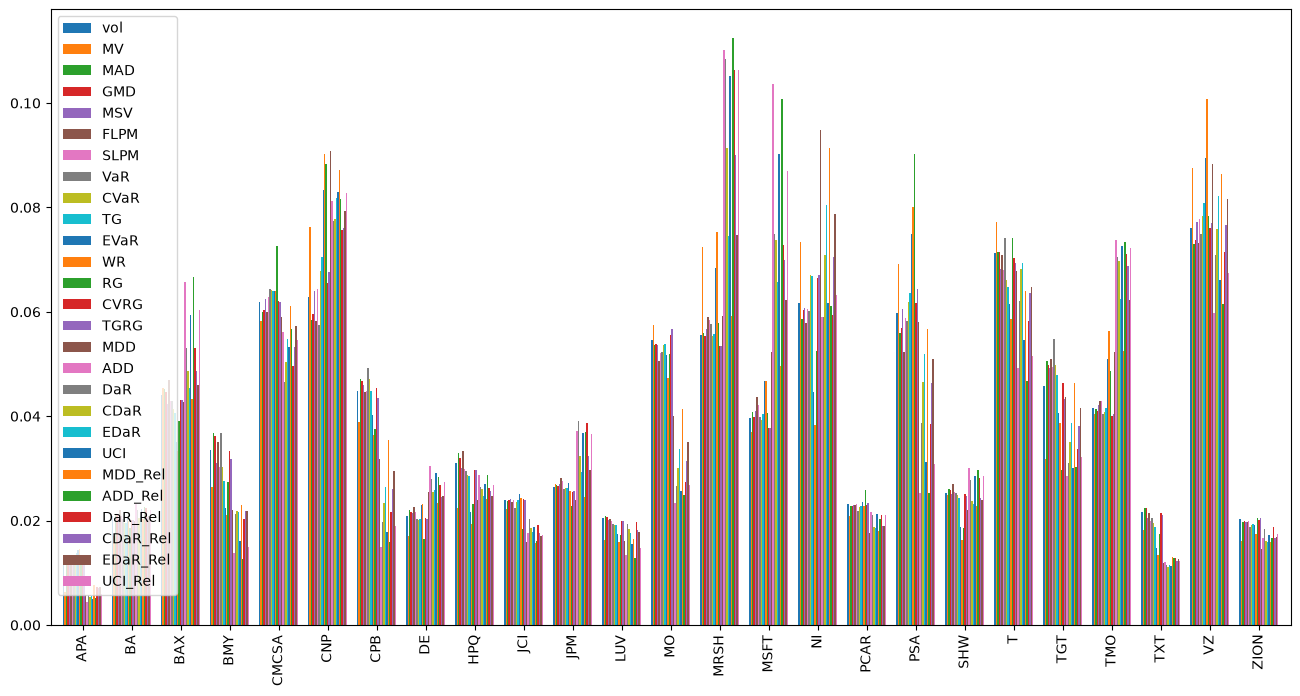

In [9]:
import matplotlib.pyplot as plt

# Plotting a comparison of assets weights for each portfolio

fig = plt.gcf()
fig.set_figwidth(16)
fig.set_figheight(8)
ax = fig.subplots(nrows=1, ncols=1)

w_s.plot(kind='bar', width=0.8, ax=ax)